In [26]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import sys

# Change root directory to the repo root (Jupyter: __file__ is not defined)
def find_repo_root(start=Path.cwd()):
	for p in [start] + list(start.parents):
		if (p / 'Code').exists() or (p / '.git').exists() or (p / 'local_repo').exists():
			return p
	return start

repo_root = find_repo_root()
data_root = repo_root.parent.parent / 'Data' / 'CBOS ready'

os.chdir(repo_root)
sys.path.append(str(repo_root / 'Code' / 'tools'))

In [27]:
df = pd.read_csv(data_root / 'CBOS_data_imputed.csv', low_memory=False)
print(f"Loaded: {df.shape[0]:,} obs × {df.shape[1]} cols, {df['survey_file'].nunique()} surveys")

Loaded: 355,352 obs × 70 cols, 327 surveys


In [ ]:
# Construct survey date from survey_month and survey_year
df['survey_date'] = pd.to_datetime(df['survey_year'].astype(str) + '-' + df['survey_month'].astype(str).str.zfill(2) + '-01')
df

/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_66738/3737364494.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['survey_date'] = pd.to_datetime(df['survey_year'].astype(str) + '-' + df['survey_month'].astype(str).str.zfill(2) + '01')


DateParseError: Unknown datetime string format, unable to parse: 1990-0101, at position 0

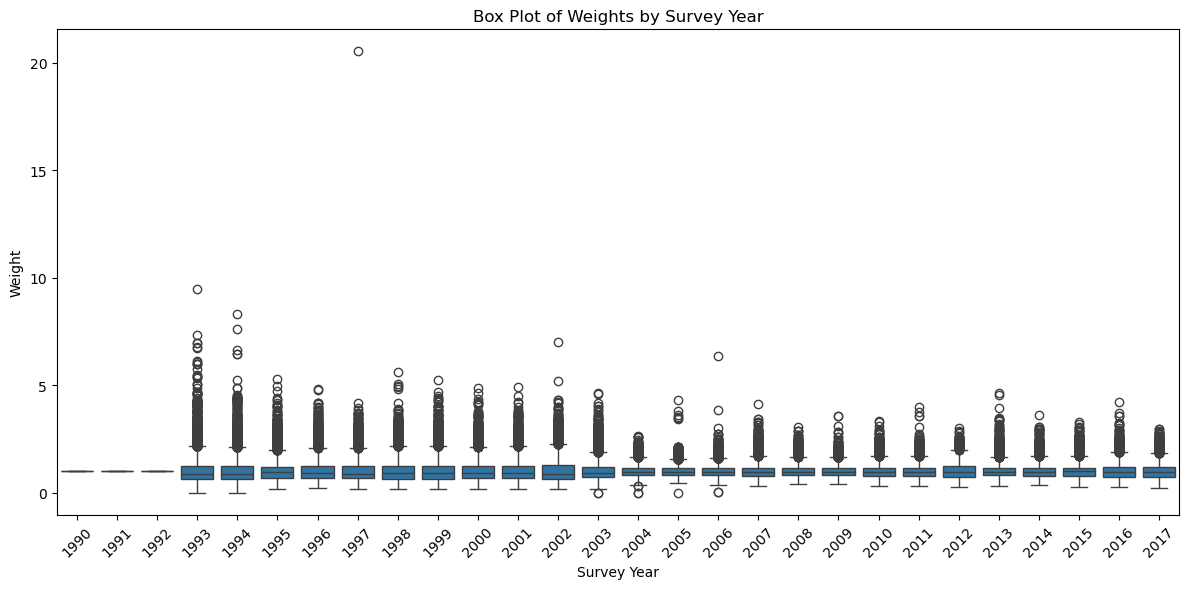

In [ ]:
# Series of box plots for each survey_month and survey_year for column weight:

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.boxplot(x='survey_year', y='weight', data=df)
plt.title('Box Plot of Weights by Survey Year')
plt.xlabel('Survey Year')
plt.ylabel('Weight')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
